# Digital Signals Theory

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import soundfile as sf

# Chapter 11: Infinite impulse response filters

## 11.1 Feedback filters

### 11.1.1. Example: exponential moving average

> As an introduction to feedback filters, let’s imagine the following process for computing a moving average of a signal $x[n]$, resulting in output signal $y[n]$.


\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= {\color{#e41a1c}\frac{1}{2}} \cdot {\color{#377eb8}x[n]} + {\color{#4daf4a}\frac{1}{2}} \cdot {\color{#984ea3}y[n-1]} & \text{(11.1)}  \\
\end{flalign}

#### Key points

* This is a **feedback** process since ${\color{#984ea3}y[n]}$ depend on both **feed-forward** process ${\color{#377eb8}x[n]}$ as well as **previous output** ${\color{#984ea3}y[n-1]}$.
* Convention is that ${\color{#984ea3}y[-1] = 0}$, so initial output value is given by ${\color{#984ea3}y[0]} = {\color{#e41a1c}\frac{1}{2}} \cdot {\color{#377eb8}x[0]}$.
* As with convolutional filters, we can analyze the behavior of (11.1) by sending an impulse signal ${\color{#377eb8}x = [1, 0, 0, \ldots]}$ into the system and seeing how it responds.

\begin{flalign}
\qquad {\color{#377eb8}x[0] = 1} \quad \Rightarrow \quad &{\color{#984ea3}y[0] = \frac{1}{2}} & \\
\qquad {\color{#377eb8}x[1] = 0} \quad \Rightarrow \quad &{\color{#984ea3}y[1] = \frac{1}{2} \cdot y[0] = \frac{1}{4}} & \\
\qquad {\color{#377eb8}x[2] = 0} \quad \Rightarrow \quad &{\color{#984ea3}y[2] = \frac{1}{2} \cdot y[1] = \frac{1}{8}} & \\
\qquad {\color{#377eb8}x[3] = 0} \quad \Rightarrow \quad &{\color{#984ea3}y[3] = \frac{1}{2} \cdot y[2] = \frac{1}{16}} & \\
\qquad     & \ldots & \\
\qquad     &{\color{#984ea3}y[n] = 2^{-(n+1)}} & \\
\end{flalign}

* _... and now we know where "exponential" comes from!_
* _Note that ${\color{#984ea3}y}$ will continue to be halved, never actually reaching zero but always approaching it, and that's where "infinite" comes from..._

### 11.1.2. IIR Filters

#### Definition 11.1 (Linear IIR filter)

The general formula for a linear IIR filter is:

\begin{flalign}
\qquad {\color{#4daf4a}a[0]} \cdot {\color{#984ea3}y[n]} &= \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]} - \sum_{k=1}^{K-1} {\color{#4daf4a}a[k]} \cdot {\color{#984ea3}y[n-k]} & \text{(11.2)}  \\
\end{flalign}

where we have:

* **feed-forward** parameters ${\color{#e41a1c}b = [b_0, b_1, b_2, \ldots b_{K-1}]}$
* **feed-back** parameters ${\color{#4daf4a}a = [a_0, a_1, a_2, \ldots a_{K-1}]}$
* in order to avoid self-dependency case ${\color{#984ea3}y[n-0] = y[n]}$, treat ${\color{#4daf4a}a[0]}$ as a special case where for all intents and purposes we assume ${\color{#4daf4a}a[0] = 1}$
* so the **feed-back** parameters are in practice assumed to be  ${\color{#4daf4a}a = [1, a_1, a_2, \ldots a_{K-1}]}$, and this why that 2nd summation is $\sum_{{\color{#4daf4a}k=1}}^{K-1}$


### 11.1.3: Special case 1: ${\color{#4daf4a}a[0] = 1}$

As long as **feed-back** parameters are such that ${\color{#4daf4a}a[0] = 1}$, we can rearrange 11.2 to yield:

\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= {\color{#4daf4a}\frac{1}{a[0]}} \cdot \left( \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]} - \sum_{k=1}^{K-1} {\color{#4daf4a}a[k]} \cdot {\color{#984ea3}y[n-k]} \right) & \\
\qquad                       &= \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]} - \sum_{k=1}^{K-1} {\color{#4daf4a}a[k]} \cdot {\color{#984ea3}y[n-k]} & \\
\end{flalign}

Looking back at 11.1 and the example of the exponential moving average, we can see:
* **feed-forward** parameters ${\color{#e41a1c}b = [\frac{1}{2}]}$
* **feed-back** parameters ${\color{#4daf4a}a = [1, -\frac{1}{2}]}$

### 11.1.4: Special case 2: ${\color{#4daf4a}a[k>0] = 0}$

In the case where **feed-back** parameters are such that ${\color{#4daf4a}a[0] = 1}$ and ${\color{#4daf4a}a[k>0] = 0}$, 11.2 reduces to _standard convolution_:

\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]}  & \\
\end{flalign}

* this means that FIR filters are a _special case of IIR!_

### 11.1.5. Causal filters

* The IIR filters we will study define ${\color{#984ea3}y[n]}$ in terms of inputs ${\color{#377eb8}x[n]}$ and with previous outputs up to and including ${\color{#984ea3}y[n-1]}$.
* Also note that for IIR, ${\color{#984ea3}y[n]}$ does **not** depend on _future values_ like ${\color{#377eb8}x[n+1]}$ or ${\color{#984ea3}y[n+1]}$.
* Systems with this property are **causal systems**.

### 11.1.6. Why are feedbacks subtracted instead of added?

* ... wait until next chapter, when we will learn about z-Transforms.

### 11.1.7. Summary

* Feedback systems _can have an infinite impulse response_, even when the input is finite in length.
* We can always assume the first feedback coefficient ${\color{#4daf4a}a[0] = 1}$.
* IIR filters generalize FIR filters.
* The feed-back terms are subtracted, not added, to produce each output ${\color{#984ea3}y[n]}$.
* In general, **feed-forward** parameters ${\color{#e41a1c}b}$ and **feed-back** parameters ${\color{#4daf4a}a}$ need not be the same length, but we can always pad the shorter of the two with zeros to make them match.

## 11.2 Using IIR filters

### 11.2.1. IIR filters in Python

[`scipy.signal.lfilter`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lfilter.html#lfilter) is a general interface for creating _linear filters_. It filters a sequence `x` using a digital filter.

At a minimum (or at least, in the examples here) the following parameters are used:
* `b`: **_array_like_**; The _numerator_ coefficient vector in a 1-D sequence.
* `a`: **_array_like_**; The _denominator_ coefficient vector in a 1-D sequence.
* `x`: **_array_like_**; An N-dimensional input array.

`lfilter` returns:
* `y`: **_array_**; The output of the digital filter.

The key point is how we obtain `b` and `a`.

In [2]:
# Compute the first few samples of the impulse response
# of an exponential moving average

x = np.array([1, 0, 0, 0, 0, 0, 0])
y = sp.signal.lfilter(
    [1/2], 
    [1, -1/2], 
    x
)

print(y)

[0.5       0.25      0.125     0.0625    0.03125   0.015625  0.0078125]


### 11.2.2. Example: Butterworth filters

In [3]:
fs = 44100  # Sampling rate
fc = 500  # Cutoff frequency

# Build the low-pass filter
b, a = sp.signal.butter(10, fc, fs=fs)

# Print the coefficients
print('Feed-forward: ', b)
print()
print('Feed-back:    ', a)

Feed-forward:  [2.62867578e-15 2.62867578e-14 1.18290410e-13 3.15441093e-13
 5.52021913e-13 6.62426296e-13 5.52021913e-13 3.15441093e-13
 1.18290410e-13 2.62867578e-14 2.62867578e-15]

Feed-back:     [   1.           -9.54462136   41.00487909 -104.41737082  174.53480697
 -200.09486144  159.34094444  -87.02835847   31.2004603    -6.6300023
    0.6341236 ]


In [4]:
# Create the delayed impulse signal
x = np.zeros(1000)
x[249] = 1

# Apply the Butterworth filter using b, a from above
y = sp.signal.lfilter(b, a, x)

In [5]:
X = np.fft.rfft(x)
Y = np.fft.rfft(y)

freqs = np.fft.rfftfreq(len(x), 1/fs)

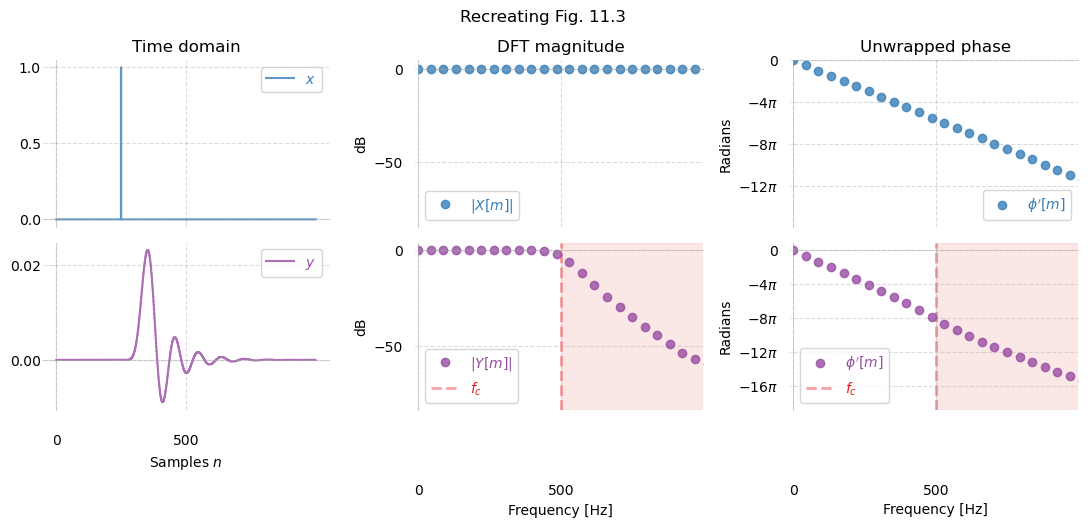

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=3, sharex='col', figsize=(11, 5))

# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 1: time domain
axes[0, 0].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[0, 0].spines['right'].set_color('none')
axes[0, 0].spines['top'].set_color('none')
axes[0, 0].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 0].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 0].set_yticks([0., 0.5, 1.])
axes[0, 0].set_xticks([0, 500])
axes[0, 0].tick_params(axis='both', which=u'both', length=3, pad=8, color='#A9A9A940')

axes[0, 0].step(np.arange(len(x)), x, where='post', label='$x$', alpha=0.8, color='#377eb8')

axes[0, 0].label_outer()
axes[0, 0].legend(loc='upper right', labelcolor='linecolor')

# BOTTOM row: y
#   column 1: time domain
axes[1, 0].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[1, 0].spines['right'].set_color('none')
axes[1, 0].spines['top'].set_color('none')
axes[1, 0].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 0].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 0].set_yticks([0., 0.02])
axes[1, 0].set_xticks([0, 500])
axes[1, 0].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[1, 0].tick_params(axis='x', which=u'both', length=3, pad=50, color='#A9A9A940')

axes[1, 0].step(np.arange(len(y)), y, where='post', label='$y$', alpha=0.8, color='#984ea3')

axes[1, 0].label_outer()
axes[1, 0].set(xlabel='Samples $n$')
axes[1, 0].legend(loc='upper right', labelcolor='linecolor')


# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 2: DFT magnitude
axes[0, 1].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
# Eliminate upper and right axes
axes[0, 1].spines['right'].set_color('none')
axes[0, 1].spines['top'].set_color('none')
axes[0, 1].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 1].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 1].set_yticks([0, -50])
axes[0, 1].set_xticks([0, 500])
axes[0, 1].tick_params(axis='both', which=u'both', length=3, pad=8, color='#A9A9A940')

axes[0, 1].step(freqs, 20 * np.log10(np.abs(X) + 1e-4), linestyle='', marker='o', label='$|X[m]|$', alpha=0.8, color='#377eb8')

axes[0, 1].set(ylim=[-85, 5])
axes[0, 1].set(ylabel='dB')
axes[0, 1].legend(loc='lower left', labelcolor='linecolor')


# BOTTOM row: y
#   column 2: DFT magnitude
axes[1, 1].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[1, 1].spines['right'].set_color('none')
axes[1, 1].spines['top'].set_color('none')
axes[1, 1].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 1].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 1].set_yticks([0, -50])
axes[1, 1].set_xticks([0, 500])
axes[1, 1].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[1, 1].tick_params(axis='x', which=u'both', length=3, pad=165, color='#A9A9A940')

axes[1, 1].step(freqs, 20 * np.log10(np.abs(Y) + 1e-4), linestyle='', marker='o', label='$|Y[m]|$', alpha=0.8, color='#984ea3')
axes[1, 1].axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
axes[1, 1].axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)

axes[1, 1].set(xlabel='Frequency [Hz]')
axes[1, 1].set(ylabel='dB')
axes[1, 1].legend(loc='lower left', labelcolor='linecolor')


# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 3: unwrapped phase
axes[0, 2].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[0, 2].spines['right'].set_color('none')
axes[0, 2].spines['top'].set_color('none')
axes[0, 2].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 2].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0, 2].set_yticks(np.linspace(0, -16*np.pi, 5), ['0', r'$-4\pi$', r'$-8\pi$', r'$-12\pi$',  r'$-16\pi$'])
axes[0, 2].set_xticks([0, 500])
axes[0, 2].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[0, 2].tick_params(axis='x', which=u'both', length=3, color='#A9A9A940')

axes[0, 2].plot(freqs, np.unwrap(np.angle(X)), linestyle='', marker='o', label=r"$\phi'[m]$", alpha=0.8, color='#377eb8')
axes[0, 2].set(ylabel="Radians")
axes[0, 2].legend(loc='lower right', labelcolor='linecolor')

# BOTTOM row: y
#   column 3: unwrapped phase
axes[1, 2].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
axes[1, 2].spines['right'].set_color('none')
axes[1, 2].spines['top'].set_color('none')
axes[1, 2].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 2].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1, 2].set_yticks(np.linspace(0, -16*np.pi, 5), ['0', r'$-4\pi$', r'$-8\pi$', r'$-12\pi$',  r'$-16\pi$'])
axes[1, 2].set_xticks([0, 500])
axes[1, 2].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[1, 2].tick_params(axis='x', which=u'both', length=3, pad=165, color='#A9A9A940')

# Eliminate upper and right axes
axes[1, 2].plot(freqs, np.unwrap(np.angle(Y)), linestyle='', marker='o', label=r"$\phi'[m]$", alpha=0.8, color='#984ea3')
axes[1, 2].axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
axes[1, 2].axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)
axes[1, 2].legend(loc='lower left', labelcolor='linecolor')
axes[1, 2].set(xlabel='Frequency [Hz]')
axes[1, 2].set(ylabel="Radians")
axes[1, 2].set(xlim=[0, 1000])


axes[1, 1].set(xlim=[0, 1000])
axes[0, 0].set(title='Time domain')
axes[0, 1].set(title='DFT magnitude')
axes[0, 2].set(title='Unwrapped phase')
axes[0, 2].set(ylim=[-50, 0.1])

fig.tight_layout()
plt.suptitle('Recreating Fig. 11.3', y=1.03)
plt.show()

##### NOTE

* Upper row in the above figure is for impulse signal $x$ where $x[249] = 1$.
* Lower row is this impulse signal put into our Butterworth filter system.

### 11.2.3. Selecting the order

For the IIR filters we're covering, the scipy way of doing things is:

1. Pick an IIR filter strategy based on your specifications and objectives (possibly easier said than done). 
2. Find the helper function (if any) for that IIR filter strategy for determining the smallest order $K$ given the specified constraints for your filter.
3. Construct the IIR filter using the order determined in 2 above, passing in any necessary arguments like cut-off frequency $f_c$ and sampling frequency $f_s$.

For the Butterworth filter:
* [`scipy.signal.buttord`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.buttord.html#buttord) is used to determine order $K$
* [`scipy.signal.butter`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html#butter) is used to construct the filter

In [7]:
fc = 500  # Cutoff at 500 Hz
fstop = 1000  # End the transition band at 1000 Hz
passband_ripple = 3  # 3dB ripple
stopband_atten = 60  # 60 dB attenuation of the stop-band

# Get the smallest order for the filter
order, _ = sp.signal.buttord(fc, fstop, passband_ripple, stopband_atten, fs=fs)
print(f"order for Butterworth filter example: {order}")

# Now construct the filter
#b, a = sp.signal.butter(order, fc, fs=fs)

# Lastly, apply the Butterworth filter to your signal x
#y = sp.signal.lfilter(b, a, x)

order for Butterworth filter example: 10


### 11.2.4. Compensating for phase distortion

Please see [`scipy.signal.filtfilt`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html#filtfilt)

In [8]:
# Build the low-pass filter for bi-directional (double) filtering
#
# This means we'll cut the pass-band ripple and stop-band attenuation both in half!
order2, _ = sp.signal.buttord(fc, fstop, passband_ripple/2, stopband_atten/2, fs=fs)

b2, a2 = sp.signal.butter(order2, fc, fs=fs)

# Apply the bi-directional filter
y2 = sp.signal.filtfilt(b2, a2, x)

In [9]:
X = np.fft.rfft(x)
Y = np.fft.rfft(y)
Y2 = np.fft.rfft(y2)

freqs = np.fft.rfftfreq(len(x), 1/fs)

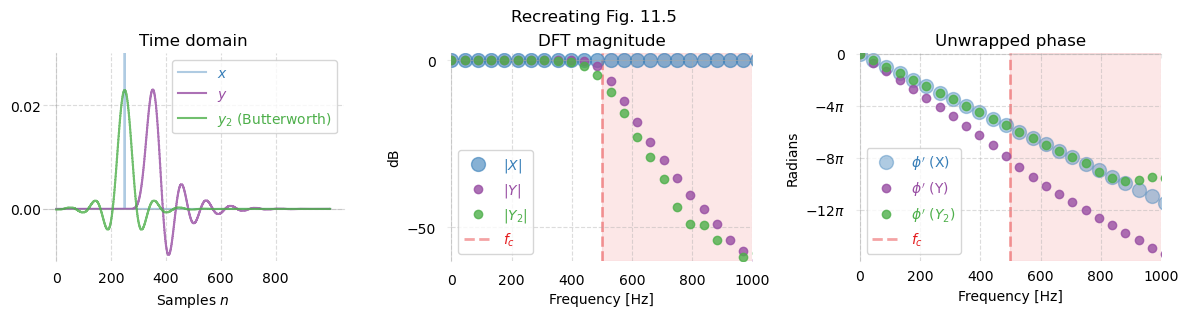

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 1: time domain
axes[0].set(title='Time domain')
axes[0].set(xlabel='Samples $n$')
axes[0].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[0].spines['right'].set_color('none')
axes[0].spines['top'].set_color('none')
axes[0].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[0].set_yticks([0., 0.02])
axes[0].set_ylim([-0.01, 0.03])
axes[0].set_xticks([0, 200, 400, 600, 800])
axes[0].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[0].tick_params(axis='x', which=u'both', length=3, pad=42, color='#A9A9A940')

axes[0].step(np.arange(len(x)), x, where='post', label='$x$', alpha=0.4, color='#377eb8', zorder=1)
axes[0].step(np.arange(len(y)), y, where='post', label='$y$', alpha=0.8, color='#984ea3', zorder=2)
axes[0].step(np.arange(len(y2)), y2, where='post', label=r'$y_2$ (Butterworth)', alpha=0.8, color='#4daf4a', zorder=20)

axes[0].label_outer()
axes[0].legend(loc='upper right', labelcolor='linecolor')


# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 2: DFT magnitude
axes[1].set(title='DFT magnitude')
axes[1].set(xlabel='Frequency [Hz]')
axes[1].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[1].spines['right'].set_color('none')
axes[1].spines['top'].set_color('none')
axes[1].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[1].set_yticks([0, -50])
axes[1].set_xticks([0, 200, 400, 600, 800, 1000])
axes[1].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[1].tick_params(axis='x', which=u'both', length=3, pad=150, color='#A9A9A940')

axes[1].step(freqs, 20 * np.log10(np.abs(X) + 1e-4), linestyle='', marker='o', markersize=10, zorder=1, label='$|X|$', alpha=0.6, color='#377eb8')
axes[1].step(freqs, 20 * np.log10(np.abs(Y) + 1e-4), linestyle='', marker='o', zorder=2, label='$|Y|$', alpha=0.8, color='#984ea3')
axes[1].step(freqs, 20 * np.log10(np.abs(Y2) + 1e-4), linestyle='', marker='o', zorder=20, label=r'$|Y_2|$', alpha=0.8, color='#4daf4a')
axes[1].axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
axes[1].axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)

axes[1].set(ylim=[-60, 2.], xlim=[-0.5, 1000])
axes[1].set(ylabel='dB')

axes[1].legend(loc='lower left', labelcolor='linecolor')


# --------------------------------------------------------------------
# TOP row: delayed signal x
#   column 3: unwrapped phase
axes[2].set(title='Unwrapped phase')
axes[2].set(xlabel='Frequency [Hz]')
axes[2].grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
axes[2].spines['right'].set_color('none')
axes[2].spines['top'].set_color('none')
axes[2].spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[2].spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
axes[2].set_yticks(np.linspace(0, -16*np.pi, 5), ['0', r'$-4\pi$', r'$-8\pi$', r'$-12\pi$',  r'$-16\pi$'])
axes[2].set_xticks([0, 200, 400, 600, 800, 1000])
axes[2].tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
axes[2].tick_params(axis='x', which=u'both', length=3, pad=152, color='#A9A9A940')

axes[2].plot(freqs, np.unwrap(np.angle(X)), linestyle='', marker='o', markersize=10, zorder=1, label=r"$\phi' \text{ (X)}$", alpha=0.4, color='#377eb8')
axes[2].plot(freqs, np.unwrap(np.angle(Y)), linestyle='', marker='o', markersize=6, zorder=2, label=r"$\phi' \text{ (Y)}$", alpha=0.8, color='#984ea3')
axes[2].plot(freqs, np.unwrap(np.angle(Y2)), linestyle='', marker='o', markersize=6, zorder=20, label=r"$\phi' \text{ (}Y_2\text{)}$", alpha=0.8, color='#4daf4a')

axes[2].axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
axes[2].axvspan(500, freqs[-1], zorder=-2, color='#e41a1c', alpha=0.1)

axes[2].set(ylim=[-60, 1.], xlim=[-0.5, 1000])
axes[2].set(ylabel="Radians")
axes[2].legend(loc='lower left', labelcolor='linecolor')

axes[2].set(ylim=[-50, 0.1])

fig.tight_layout()
plt.suptitle('Recreating Fig. 11.5', y=1.03)
plt.show()

#### Take-away points for IIR filters so far...

* The double-filtering approach effectively aligns the final output to the input, as evidenced by the time-domain representations peaking in exactly the same sample index.
* However, note that reverse-filtering introduces pre-echo: the oscillations in $y_2$ preceding the peak at $n = 249$.
* This result is similar to the FIR filter outputs in chapter 10, (c.f. [Fig. 10.8](https://brianmcfee.net/dstbook-site/content/ch10-convtheorem/FilterDesign.html#pmfir)), and is to some extent unavoidable if we’re applying low-pass filtering to signals with strong transients.
* Remember: although the outputs are similar, we got there with much less work: an order-6 IIR filter applied twice, compares well to FIR filters with order in the hundreds.

## 11.3. Common IIR filters

* We are going to make comparisons between the Butterworth, Chebyshev Type-1 and Type-2, and finally elliptic filters.
* To compare these filters, we need to look at their filter kernels.
* We obtain the filter kernels by feeding an impulse response into each filter.

We start with an $N = 2000$ sample impulse reponse $x$.

In [11]:
# x will be a normal unit impulse
N = 2000

x = np.zeros(N)
x[0] = 1

We will keep the following values:

* cut-off frequency $f_c$ will be set via `fc` as 500 Hz
* ending the transition-band via `fstop` as 1000 Hz
* allow for pass-band ripple `passband_ripple` of 3 dB
* require attentuation in the stop-band `stopband_atten` to be maximum -60 dB

NOTE that we will be setting order $K$ for all filter based on the best value for the _Chebyshev filters_. This means we will have to recalculate the Butterworth filter as well.

In [12]:
# re-do X, etc.
X = np.fft.rfft(x)

freqs = np.fft.rfftfreq(N, 1/fs)

In [13]:
# Get the smallest order for the Butterworth filter
order_butt, _ = sp.signal.buttord(fc, fstop, passband_ripple, stopband_atten, fs=fs)
print(f"order for our Butterworth filter: {order_butt}")

# Now construct the Butterworth filter
b_butt, a_butt = sp.signal.butter(order_butt, fc, fs=fs)
y_butt = sp.signal.lfilter(b_butt, a_butt, x)

# DFT magnitude for Butterworth filter result
Y_butt = np.fft.rfft(y_butt)

order for our Butterworth filter: 10


### 11.3.1. Chebyshev filters

#### 11.3.1.1. Type 1

* Please see [`scipy.signal.cheb1ord`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.cheb1ord.html#cheb1ord) for the helper function to determine suitable order $K$.
* Also see [`scipy.signal.cheby1`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cheby1.html#cheby1) for the helper function that constructs the filter (computes $b$ and $a$).
* Note that when constructing a Chebyshev Type 1 filter, we specify <span style="background-color:#3FF;">_pass-band ripple_</span> and the <span style="background-color:#3FF;">_cut-off frequency_</span>.

In [14]:
# Get the smallest order for the Chebyshev Type-1 filter
order_cheby1, _ = sp.signal.cheb1ord(fc, fstop, passband_ripple, stopband_atten, fs=fs)
print(f"order for our Chebyshev Type-1 filter: {order_cheby1}")

# Build the filter, passing in:
# - max. allowed pass-band ripple
# - the cutoff frequency
b_cheby1, a_cheby1 = sp.signal.cheby1(order_cheby1, passband_ripple, fc, fs=fs)

# Apply the Type 1 Chebyshev filter
y_cheby1 = sp.signal.lfilter(b_cheby1, a_cheby1, x)

# DFT magnitude, Chebyshev Type-1 result
Y_cheby1 = np.fft.rfft(y_cheby1)

order for our Chebyshev Type-1 filter: 6


#### 11.3.1.2. Type 2

* Please see [`scipy.signal.cheb2ord`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cheb2ord.html#cheb2ord) for the helper function to determine suitable order $K$.
* Also see [`scipy.signal.cheby2`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cheby2.html#cheby2) for the helper function that constructs the filter (computes $b$ and $a$).
* Note that in contrast to how we constructed the filter for Chebyshev Type 1, here we specify <span style="background-color:#3FF;">_stop-band attentuation_</span> and the <span style="background-color:#3FF;">_ending edge of the transition band_</span>.

In [15]:
# Get the smallest order for the Chebyshev Type-2 filter
order_cheby2, _  = sp.signal.cheb2ord(fc, fstop, passband_ripple, stopband_atten, fs=fs)
print(f"order for our Chebyshev Type-2 filter: {order_cheby2}")

# Build the filter, passing in:
# - stop-band attenuation
# - the end of the transition band region
b_cheby2, a_cheby2 = sp.signal.cheby2(order_cheby2, stopband_atten, fstop, fs=fs)

# Apply the Type 2 Chebyshev filter
y_cheby2 = sp.signal.lfilter(b_cheby2, a_cheby2, x)

# DFT magnitude, Chebyshev Type-2 result
Y_cheby2 = np.fft.rfft(y_cheby2)

order for our Chebyshev Type-2 filter: 6


##### Observations in the Time domain

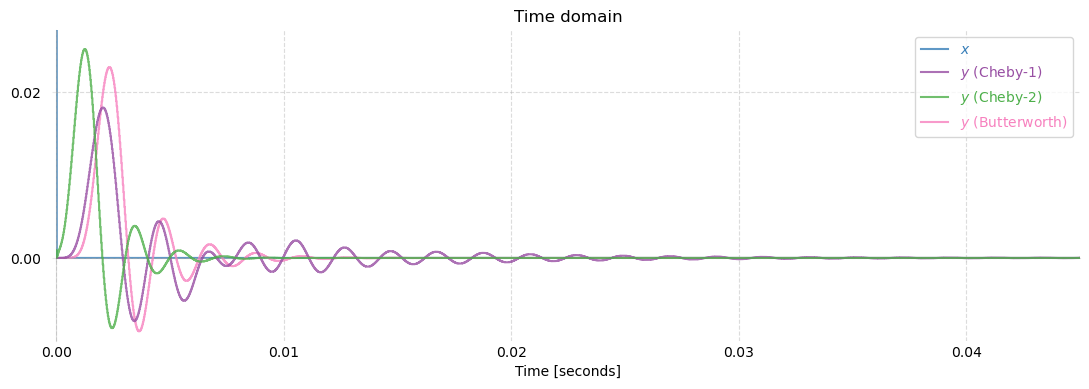

In [16]:
# --------------------------------------------------------------------
# Time domain: compare x, y (Cheby-1), y (Cheby-2), and y (Butterworth)
#
fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title = 'Time domain')
ax.set(xlabel='Time [seconds]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0., 0.02])
ax.set_ylim([-0.01, 0.0275])
ax.set_xlim([-0.00001, 0.045])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=60, color='#A9A9A940')

ax.step(np.arange(N) / fs, x, where='post', label='$x$', alpha=0.8, color='#377eb8', zorder=1)
ax.step(np.arange(N) / fs, y_cheby1, where='post', label='$y$ (Cheby-1)', alpha=0.8, color='#984ea3', zorder=3)
ax.step(np.arange(N) / fs, y_cheby2, where='post', label='$y$ (Cheby-2)', alpha=0.8, color='#4daf4a', zorder=4)
ax.step(np.arange(N) / fs, y_butt, where='post', label='$y$ (Butterworth)', alpha=0.8, color='#f781bf', zorder=2)

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')

plt.show()

* ???

##### Observations in Frequency response

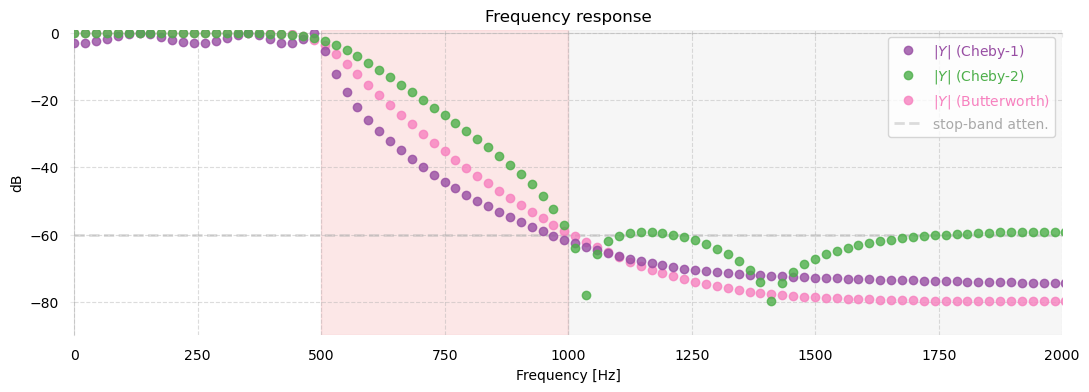

In [17]:
# --------------------------------------------------------------------
# DFT magnitude: compare X, Y (Cheby-1), Y (Cheby-2), and Y (Butterworth)
#
fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Frequency response')
ax.set(xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0, -20, -40, -60, -80])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=224, color='#A9A9A940')

#ax.step(freqs, 20 * np.log10(np.abs(X) + 1e-4), linestyle='', marker='o', markersize=10, zorder=1, label=r'$|X|$', alpha=0.4, color='#377eb8')
ax.step(freqs, 20 * np.log10(np.abs(Y_cheby1) + 1e-4), linestyle='', marker='o', zorder=3, label='$|Y|$ (Cheby-1)', alpha=0.8, color='#984ea3')
ax.step(freqs, 20 * np.log10(np.abs(Y_cheby2) + 1e-4), linestyle='', marker='o', zorder=4, label='$|Y|$ (Cheby-2)', alpha=0.8, color='#4daf4a')
ax.step(freqs, 20 * np.log10(np.abs(Y_butt) + 1e-4), linestyle='', marker='o', zorder=2, label='$|Y|$ (Butterworth)', alpha=0.8, color='#f781bf')

ax.axvspan(500, 1000, zorder=-2, color='#e41a1c', alpha=0.1)
ax.axvspan(1000, freqs[-1], zorder=-2, color='#A9A9A9', alpha=0.1)

ax.axhline(-60, label='stop-band atten.', zorder=-1, linewidth=2, color='#A9A9A9', linestyle='--', alpha=0.4)

ax.set(ylim=[-90, 1.], xlim=[-0.5, 2000])
ax.set(ylabel='dB')

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')

plt.show()

* _Both <span style="background-color:rgba(77,175,74,0.3)">Chebyshev Type-2</span> and <span style="background-color:rgba(247,129,191,0.3)">Butterworth</span> show very little ripple in the pass-band, if any._
* _<span style="background-color:rgba(152,78,163,0.3)">Chebyshev Type-1</span> has the steepest transition._
* _<span style="background-color:rgba(77,175,74,0.3)">Chebyshev Type-2</span> has ripple in the stop-band._

##### Observations in unwrapped phase

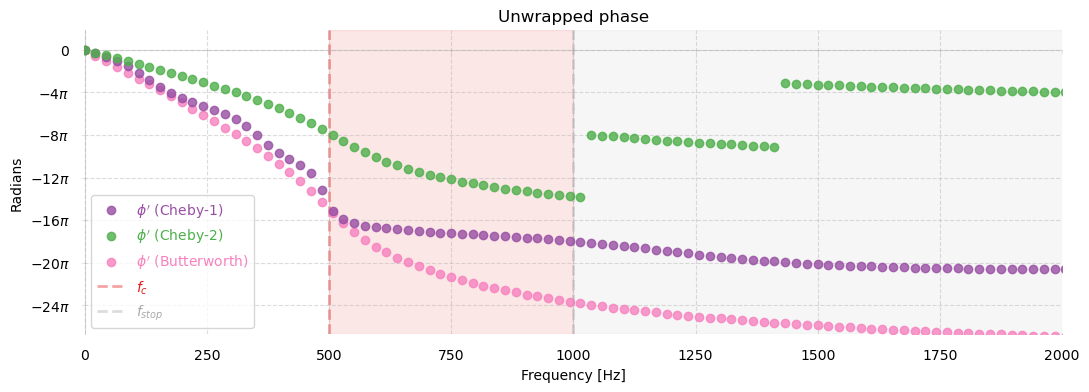

In [18]:
# --------------------------------------------------------------------
# Unwrapped phase: compare X, Y (Cheby-1), Y (Cheby-2), and Y (Butterworth)
#
fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Unwrapped phase')
ax.set(xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks(np.linspace(0, -4*np.pi, 7), ['0', r'$-4\pi$', r'$-8\pi$', r'$-12\pi$', r'$-16\pi$', r'$-20\pi$', r'$-24\pi$'])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=212, color='#A9A9A940')

ax.plot(freqs, np.unwrap(np.angle(Y_cheby1)), linestyle='', marker='o', markersize=6, zorder=3, label=r"$\phi'$ (Cheby-1)", alpha=0.8, color='#984ea3')
ax.plot(freqs, np.unwrap(np.angle(Y_cheby2)), linestyle='', marker='o', markersize=6, zorder=4, label=r"$\phi'$ (Cheby-2)", alpha=0.8, color='#4daf4a')
ax.plot(freqs, np.unwrap(np.angle(Y_butt)), linestyle='', marker='o', markersize=6, zorder=2, label=r"$\phi'$ (Butterworth)", alpha=0.8, color='#f781bf')

ax.axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
ax.axvspan(500, 1000, zorder=-2, color='#e41a1c', alpha=0.1)
ax.axvline(1000, zorder=-1, label='$f_{stop}$', linewidth=2, color='#A9A9A9', linestyle='--', alpha=0.4)
ax.axvspan(1000, freqs[-1], zorder=-2, color='#A9A9A9', alpha=0.1)

ax.set(ylim=[-14, 1.], xlim=[-0.5, 2000])
ax.set(ylabel='Radians')

fig.tight_layout()
ax.legend(loc='lower left', labelcolor='linecolor')

plt.show()

* ???

### 11.3.2. Elliptic filters

The score so far:

* <span style="background-color:rgba(247,129,191,0.3)">Butterworth filter</span>, as the textbook explains, has no ripple in pass-band nor in stop-band
* <span style="background-color:rgba(152,78,163,0.3)">Chebyshev Type-1</span> has pass-band ripple. Phase in the stop-band appears to be linear, but attenuation does seem to reach the specified -60 dB level.
* <span style="background-color:rgba(77,175,74,0.3)">Chebyshev Type-2</span> has no pass-band ripple, and in the stop-band phase looks to be linear and attentuation reaches and dives lower than the specified -60 dB.

> If we allow ripple in both the pass- and stop-bands, we get what are known as _elliptic filters_. The main benefit of elliptic filters is that they can have extremely steep transitions.

So we will now try out an Elliptic filter and see how they all compare.

Please see:
* [`scipy.signal.ellipord`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.ellipord.html#ellipord) for the helper function to determine suitable order $K$.
* [`scipy.signal.ellip`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.ellip.html#ellip) for the helper function that constructs the filter (computes $b$ and $a$).

In [19]:
# Get the smallest order for the Elliptic filter
order_ell, _  = sp.signal.ellipord(fc, fstop, passband_ripple, stopband_atten, fs=fs)
print(f"order for our Elliptic filter: {order_ell}")

# Build the filter
b_ell, a_ell = sp.signal.ellip(order_ell, passband_ripple, stopband_atten, fc, fs=fs)

# Apply the Elliptic filter
y_ell = sp.signal.lfilter(b_ell, a_ell, x)
Y_ell = np.fft.rfft(y_ell)

order for our Elliptic filter: 5


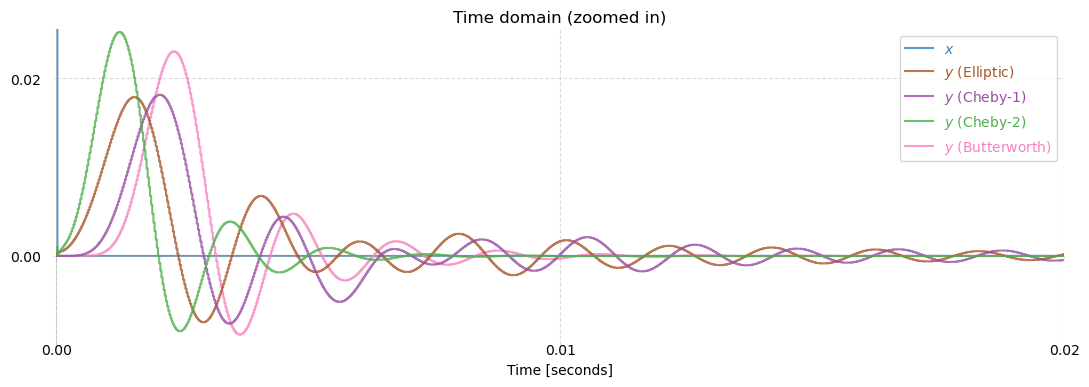

In [20]:
# --------------------------------------------------------------------
# Time domain: compare x, y (Cheby-1), y (Cheby-2), y (Butterworth), and y (Elliptic)
#
fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title = 'Time domain (zoomed in)')
ax.set(xlabel='Time [seconds]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0., 0.02])
ax.set_ylim([-0.01, 0.0255])
ax.set_xticks([0., 0.01, 0.02])
ax.set_xlim([-0.00001, 0.02])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=60, color='#A9A9A940')

ax.step(np.arange(N) / fs, x, where='post', label='$x$', alpha=0.8, color='#377eb8', zorder=1)
ax.step(np.arange(N) / fs, y_ell, where='post', label='$y$ (Elliptic)', alpha=0.8, color='#a65628', zorder=3)
ax.step(np.arange(N) / fs, y_cheby1, where='post', label='$y$ (Cheby-1)', alpha=0.8, color='#984ea3', zorder=3)
ax.step(np.arange(N) / fs, y_cheby2, where='post', label='$y$ (Cheby-2)', alpha=0.8, color='#4daf4a', zorder=4)
ax.step(np.arange(N) / fs, y_butt, where='post', label='$y$ (Butterworth)', alpha=0.8, color='#f781bf', zorder=2)

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')

plt.show()

* ???

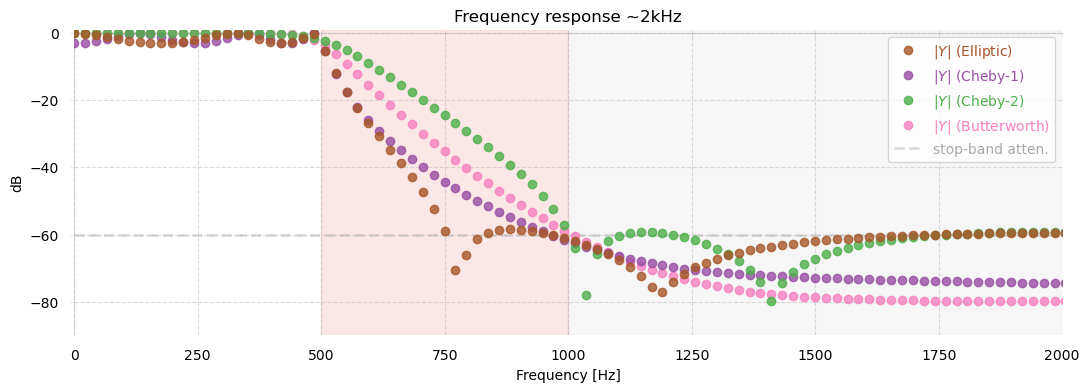

In [21]:
# --------------------------------------------------------------------
# Frequency response: compare X, Y (Cheby-1), Y (Cheby-2), Y (Butterworth), and Y (Elliptic)
#
fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Frequency response ~2kHz')
ax.set(xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0, -20, -40, -60, -80])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=224, color='#A9A9A940')

ax.step(freqs, 20 * np.log10(np.abs(Y_ell) + 1e-4), linestyle='', marker='o', zorder=5, label=r'$|Y|$ (Elliptic)', alpha=0.8, color='#a65628')
ax.step(freqs, 20 * np.log10(np.abs(Y_cheby1) + 1e-4), linestyle='', marker='o', zorder=3, label='$|Y|$ (Cheby-1)', alpha=0.8, color='#984ea3')
ax.step(freqs, 20 * np.log10(np.abs(Y_cheby2) + 1e-4), linestyle='', marker='o', zorder=4, label='$|Y|$ (Cheby-2)', alpha=0.8, color='#4daf4a')
ax.step(freqs, 20 * np.log10(np.abs(Y_butt) + 1e-4), linestyle='', marker='o', zorder=2, label='$|Y|$ (Butterworth)', alpha=0.8, color='#f781bf')

ax.axvspan(500, 1000, zorder=-2, color='#e41a1c', alpha=0.1)
ax.axvspan(1000, freqs[-1], zorder=-2, color='#A9A9A9', alpha=0.1)

ax.axhline(-60, label='stop-band atten.', zorder=-1, linewidth=2, color='#A9A9A9', linestyle='--', alpha=0.4)

ax.set(ylim=[-90, 1.], xlim=[-0.5, 2000])
ax.set(ylabel='dB')

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')

plt.show()

* _OK, so it **does** appear that the <span style="background-color:rgba(166,86,40,0.3)">Elliptic filter</span> results in a steeper transition than both <span style="background-color:rgba(152,78,163,0.3)">Chebyshev Type-1</span> and <span style="background-color:rgba(77,175,74,0.3)">Type-2</span>._

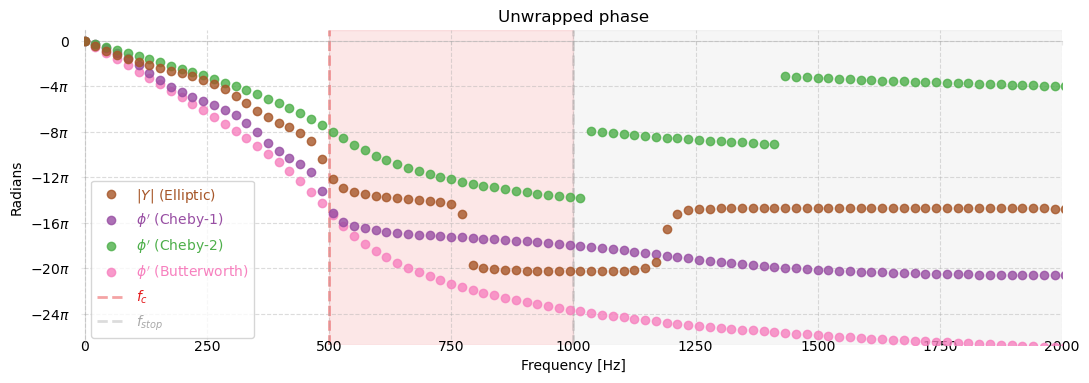

In [22]:
# --------------------------------------------------------------------
# Unwrapped phase: compare X, Y (Cheby-1), Y (Cheby-2), Y (Butterworth), and finally Y (Elliptic)
#
fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Unwrapped phase')
ax.set(xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks(np.linspace(0, -4*np.pi, 7), ['0', r'$-4\pi$', r'$-8\pi$', r'$-12\pi$', r'$-16\pi$', r'$-20\pi$', r'$-24\pi$'])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=212, color='#A9A9A940')

ax.plot(freqs, np.unwrap(np.angle(Y_ell)), linestyle='', marker='o', markersize=6, zorder=5, label=r'$|Y|$ (Elliptic)', alpha=0.8, color='#a65628')
ax.plot(freqs, np.unwrap(np.angle(Y_cheby1)), linestyle='', marker='o', markersize=6, zorder=3, label=r"$\phi'$ (Cheby-1)", alpha=0.8, color='#984ea3')
ax.plot(freqs, np.unwrap(np.angle(Y_cheby2)), linestyle='', marker='o', markersize=6, zorder=4, label=r"$\phi'$ (Cheby-2)", alpha=0.8, color='#4daf4a')
ax.plot(freqs, np.unwrap(np.angle(Y_butt)), linestyle='', marker='o', markersize=6, zorder=2, label=r"$\phi'$ (Butterworth)", alpha=0.8, color='#f781bf')

ax.axvline(500, zorder=-1, label='$f_c$', linewidth=2, color='#e41a1c', linestyle='--', alpha=0.4)
ax.axvspan(500, 1000, zorder=-2, color='#e41a1c', alpha=0.1)
ax.axvline(1000, zorder=-1, label='$f_{stop}$', linewidth=2, color='#A9A9A9', linestyle='--', alpha=0.4)
ax.axvspan(1000, freqs[-1], zorder=-2, color='#A9A9A9', alpha=0.1)

ax.set(ylim=[-14, 0.5], xlim=[-0.5, 2000])
ax.set(ylabel='Radians')

fig.tight_layout()
ax.legend(loc='lower left', labelcolor='linecolor')

plt.show()

* _But when compared with <span style="background-color:rgba(152,78,163,0.3)">Chebyshev Type-1</span> and <span style="background-color:rgba(77,175,74,0.3)">Type-2</span>, <span style="background-color:rgba(166,86,40,0.3)">Elliptic</span> also results in more phase distortion._

### 11.3.3. Summary

* IIR filters are very well-suited for real-time filtering; they are often preferred in resource-constrained or low-latency applications.
* IIR filters can achieve sharp roll-offs with lower filter order compared to FIR filters, with fewer multiplications and memory accesses per output sample.
* With fewer coefficients, IIR filters introduce less delay compared to FIR filters for the same frequency response.
* But _phase distortion_ may result, affecting signal shape in undesirable ways.

#### Quick recap of the IIR filters we've just seen

<div style="display: inline-block">
    
| Filter type           | Pass-band ripple | Stop-band ripple | Transition | Phase distortion |       
| --------------------- | ---------------- | ---------------- | ---------- | ---------------- |
| <span style="background-color:rgba(247,129,191,0.3)">Butterworth</span>           | no               | no               | slow       | small            |
| <span style="background-color:rgba(152,78,163,0.3)">Chebyshev Type-1</span>    | yes              | no               | medium     | medium           |
| <span style="background-color:rgba(77,175,74,0.3)">Chebyshev Type-2</span>    | no               | yes              | medium     | small            |
| <span style="background-color:rgba(166,86,40,0.3)">Elliptic</span>              | yes              | yes              | fast       | large            |

</div>


1. If you do not want any attenuation of pass-band frequencies, choose <span style="background-color:rgba(247,129,191,0.3)">Butterworth</span> or <span style="background-color:rgba(77,175,74,0.3)">Chebyshev Type-2</span>.
2. How much phase distortion can you tolerate? Or can you compensate for it by using _bi-directional filtering_?
3. If you need steep transitions, <span style="background-color:rgba(166,86,40,0.3)">Elliptic</span> might be the best option.

----

### 11.4. Exercises

#### Exercise 11.1

Given this IIR system:

\begin{flalign}
\qquad y[n] &= \frac{1}{2} \left( x[n] - x[n-2] \right) + y[n-1] &  \\
\end{flalign}

1. _What is the order of this system?_
2. _Put this system into the standard form of (11.2). What are ${\color{#4daf4a}a}$ and ${\color{#e41a1c}b}$ for this system?_
3. _What is its impulse response?

<hr style='border-top:0px; max-width:500px; margin-left:0;'>

We can expand the above equation like so:

\begin{flalign}
\qquad y[n] &= \frac{1}{2} \cdot x[n] + 0 \cdot x[n-1] + -\frac{1}{2} \cdot x[n-2]  - (-1) \cdot y[n-1] &  \\
\end{flalign}

Hence:

* ${\color{#e41a1c}b} = [\frac{1}{2}, 0, -\frac{1}{2}]$
* ${\color{#4daf4a}a} = [1, -1]$



##### _Answer_
1. _We can take order as `max(len(a), len(b)) - 1`, so order $K = 2$_

2. _Standard form per (11.2) of this system is given by:_

\begin{flalign}
\qquad y[n] &= \sum_{k=0}^{2} {\color{#e41a1c}b[k]} \cdot x[n-k] - \sum_{k=1}^{2} {\color{#4daf4a}a[k]} \cdot y[n-k] & \\
\end{flalign}


3. _Plugging in an impulse signal $x = [1, 0, 0, 0, 0, \ldots]$ into our system yields:_

\begin{flalign}
\qquad x[0] = 1 \quad \Rightarrow \quad &y[0] = \frac{1}{2} \left( x[0] - x[-2] \right) + y[-1] = \frac{1}{2} & \\
\qquad x[1] = 0 \quad \Rightarrow \quad &y[1] = \frac{1}{2} \left( x[1] - x[-1] \right) + y[0] = \frac{1}{2} & \\
\qquad x[2] = 0 \quad \Rightarrow \quad &y[2] = \frac{1}{2} \left( x[2] - x[0] \right) + y[1] = 0 & \\
\qquad x[3] = 0 \quad \Rightarrow \quad &y[3] = \frac{1}{2} \left( x[3] - x[1] \right) + y[2] = 0 & \\
\qquad x[4] = 0 \quad \Rightarrow \quad &y[4] = \frac{1}{2} \left( x[4] - x[2] \right) + y[3] = 0 & \\
\qquad     & \ldots & \\
\end{flalign}

_... since the frequency response of our system actually reaches 0 from after $n=2$, our system is actually **FIR**!_

In [23]:
# let's just double-check our answer
x = [1, 0, 0, 0, 0]

b = [1/2, 0, -1/2]
a = [1, -1]

y = sp.signal.lfilter(b, a, x)
y

array([0.5, 0.5, 0. , 0. , 0. ])

----

#### Exercise 11.2

Construct a **high-pass** Butterworth filter with these parameters:

* sampling frequency $f_s$ = 44100
* cut-off frequency $f_c$ = 500 Hz
* transition width of 250 Hz; $f_{stop}$ = 500 + 250 = 750 Hz
* pass-band loss (ripple) of at most 1 dB
* stop-band attenuation of 60 dB

_What is the order of such a filter?_

Please refer to [`scipy.signal.buttord`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.buttord.html#buttord).

<hr style='border-top:0px; max-width:500px; margin-left:0;'>

##### _Answer_

In terms of `scipy.signal.buttord` arguments in the case of a high-pass Butterworth filter we need:

* _wp_ = 750 Hz
* _ws_ = 500 Hz
* _gpass_ = 1 dB
* _gstop_ = 60 dB
* _fs_ = 44100 Hz

In [24]:
order, _ = sp.signal.buttord(750, 500, 1, 60, fs=44100)
print(f"Order K = {order}")

Order K = 19


----

#### Exercise 11.3

Implement a **low-pass** filter with the following specifications:

* sampling frequency $f_s$ = 44100
* cut-off frequency $f_c$ = 1000 Hz
* pass-band loss (ripple) of <span style="background-color:#3FF;">at most 1.5 dB (**less** is acceptable)</span>
* stop-band attenuation of <span style="background-color:#3FF;">at least 80 dB (**more** is acceptable)</span>
* transition width of <span style="background-color:#3FF;">max. 500 Hz (**less** is acceptable)</span>

1. Which of the IIR filter(s) covered in this chapter could you use to implement a filter with these constraints?
2. Using the helper functions provided by `scipy` (e.g., `scipy.signal.*ord`), determine the order of the filter. If there are multiple filter types that will work, which one gives the smallest order?
3. Use the Parks-McClellan method (c.f. [`scipy.signal.remez`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.remez.html#remez)) to implement an FIR filter with the given constraints. What order does the filter need to be to satisfy the constraints?

Just stick to basic single-pass (i.e., `scipy.signal.lfilter`) filters in this exercise; don't use any bi-directional (i.e., `scipy.signal.filtfilt`) approaches.

<hr style='border-top:0px; max-width:500px; margin-left:0;'>

Off the top of my head, I would guess that all four of the IIR filters we've seen in this chapter might work.

So... why not analyze the frequency responses for all of them using the given specifications and see?

In [25]:
# filter specifications
fs = 44100
fc = 1000
fstop = 1500
passband_ripple = 1.5
stopband_atten = 80

In [26]:
# x will be a normal unit impulse
N = 2000

x = np.zeros(N)
x[0] = 1

In [27]:
freqs = np.fft.rfftfreq(N, 1/fs)

##### Butterworth

Some interesting findings on using Butterworth with the above specifications!

* using `scipy.signal.buttord` to determine order, 
* It looks like given pass-band loss (ripple) of <span style="background-color:#3FF;">at most 1.5 dB (**less** is acceptable)</span>; stop-band attenuation of <span style="background-color:#3FF;">at least 80 dB (**more** is acceptable)</span>; and transition width of <span style="background-color:#3FF;">max. 500 Hz (**less** is acceptable)</span>, we cannot use the Butterworth filter!

##### Notes on Butterworth filter and the pass-band ripple requirement

* Butterworth filter stability only really improves when allowing pass-band ripple to increase greatly.
* This indicates that the Butterworth filter may not satisfy the requirement of a pass-band loss (ripple) of <span style="background-color:#3FF;">at most 1.5 dB (**less** is acceptable)</span>.
* In the graph below, we try out pass-band ripple values of 30, 40 and 50 dB.

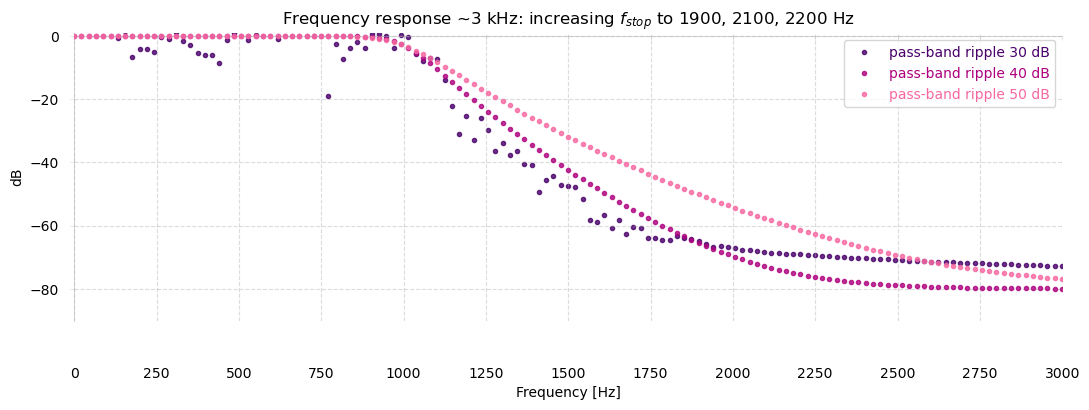

In [28]:
butt_check = {}
for k in [30, 40, 50]:
    _order, _ = sp.signal.buttord(fc, fstop, k, 80, fs=fs)
    _b, _a = sp.signal.butter(_order, fc, btype='low', fs=fs)
    _y = sp.signal.lfilter(_b, _a, x)
    butt_check[k] = np.fft.rfft(_y)

fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Frequency response ~3 kHz: increasing $f_{stop}$ to 1900, 2100, 2200 Hz')
ax.set(ylabel='dB', xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0, -20, -40, -60, -80])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=235, color='#A9A9A940')

ax.step(freqs, 20 * np.log10(np.abs(butt_check[30]) + 1e-4), linestyle='', marker='.', zorder=1, label='pass-band ripple 30 dB', alpha=0.8, color='#49006a')
ax.step(freqs, 20 * np.log10(np.abs(butt_check[40]) + 1e-4), linestyle='', marker='.', zorder=2, label='pass-band ripple 40 dB', alpha=0.8, color='#ae017e')
ax.step(freqs, 20 * np.log10(np.abs(butt_check[50]) + 1e-4), linestyle='', marker='.', zorder=3, label='pass-band ripple 50 dB', alpha=0.8, color='#f768a1')

ax.set(ylim=[-90., 0.9], xlim=[-0.5, 3000])
ax.set(ylabel='dB')

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')
plt.show()

##### Notes on Butterworth filter and the stop-band attenuation requirement

* Min. 80 dB for stop-band attenuation is very aggressive, and in general filter order will grows the higher this value is.
* Keeping all of the requirements fixed and only letting stop-band attenuation to take lower values do we see the Butterworth filter become stable.
* This indicates that the Butterworth filter might not also satisfy the requirement of a stop-band attenuation of <span style="background-color:#3FF;">at least 80 dB (**more** is acceptable)</span>.
* In the graph below, we try out stop-band attenuation values of 44, 40, and 30 dB.

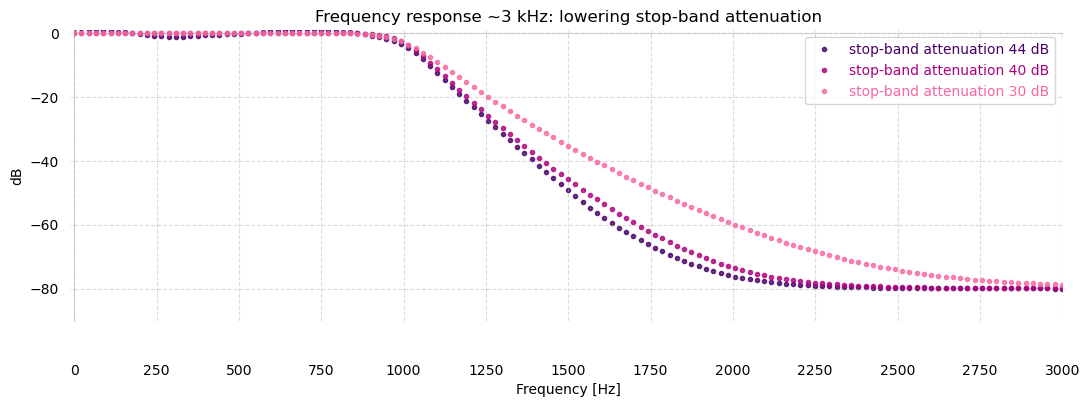

In [29]:
butt_check = {}
for k in [44, 40, 30]:
    _order, _ = sp.signal.buttord(fc, fstop, 1.5, k, fs=fs)
    _b, _a = sp.signal.butter(_order, fc, btype='low', fs=fs)
    _y = sp.signal.lfilter(_b, _a, x)
    butt_check[k] = np.fft.rfft(_y)


fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Frequency response ~3 kHz: lowering stop-band attenuation')
ax.set(ylabel='dB', xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0, -20, -40, -60, -80])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=235, color='#A9A9A940')

ax.step(freqs, 20 * np.log10(np.abs(butt_check[44]) + 1e-4), linestyle='', marker='.', zorder=1, label='stop-band attenuation 44 dB', alpha=0.8, color='#49006a')
ax.step(freqs, 20 * np.log10(np.abs(butt_check[40]) + 1e-4), linestyle='', marker='.', zorder=2, label='stop-band attenuation 40 dB', alpha=0.8, color='#ae017e')
ax.step(freqs, 20 * np.log10(np.abs(butt_check[30]) + 1e-4), linestyle='', marker='.', zorder=3, label='stop-band attenuation 30 dB', alpha=0.8, color='#f768a1')

ax.set(ylim=[-90., 0.9], xlim=[-0.5, 3000])
ax.set(ylabel='dB')

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')
plt.show()

##### Notes on Butterworth filter and the transition width requirement

* Butterworth filter stability only really improves when allowing $f_{stop}$ to increase greatly.
* This indicates that the Butterworth filter cannot also satisfy the requirement of a transition width of <span style="background-color:#3FF;">max. 500 Hz (**less** is acceptable)</span>.

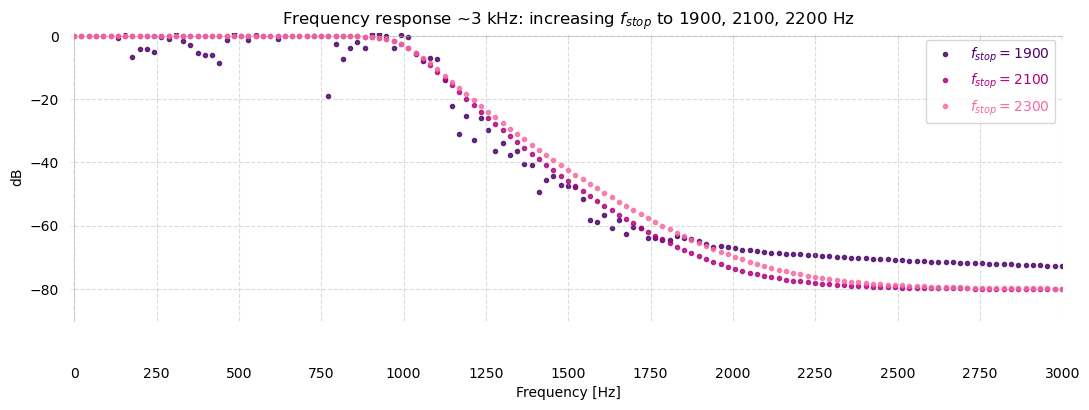

In [30]:
butt_check = {}
for k in [1900, 2100, 2300]:
    _order, _ = sp.signal.buttord(fc, k, 1.5, 80, fs=fs)
    _b, _a = sp.signal.butter(_order, fc, btype='low', fs=fs)
    _y = sp.signal.lfilter(_b, _a, x)
    butt_check[k] = np.fft.rfft(_y)


fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Frequency response ~3 kHz: increasing $f_{stop}$ to 1900, 2100, 2200 Hz')
ax.set(ylabel='dB', xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0, -20, -40, -60, -80])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=235, color='#A9A9A940')

ax.step(freqs, 20 * np.log10(np.abs(butt_check[1900]) + 1e-4), linestyle='', marker='.', zorder=1, label='$f_{stop}=1900$', alpha=0.8, color='#49006a')
ax.step(freqs, 20 * np.log10(np.abs(butt_check[2100]) + 1e-4), linestyle='', marker='.', zorder=2, label='$f_{stop}=2100$', alpha=0.8, color='#ae017e')
ax.step(freqs, 20 * np.log10(np.abs(butt_check[2300]) + 1e-4), linestyle='', marker='.', zorder=3, label='$f_{stop}=2300$', alpha=0.8, color='#f768a1')

ax.set(ylim=[-90., 0.9], xlim=[-0.5, 3000])
ax.set(ylabel='dB')

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')
plt.show()

##### Conclusion: looks like we need to toss out the Butterworth filter in this case!

In [31]:
# Get the smallest order for the Chebyshev Type-1 filter
order_cheby1, _ = sp.signal.cheb1ord(fc, fstop, passband_ripple, stopband_atten, fs=fs)
print(f"Ex. 11.3: order for our Chebyshev Type-1 filter: {order_cheby1}")

# Build the filter, passing in:
# - max. allowed pass-band ripple
# - the cutoff frequency
b_cheby1, a_cheby1 = sp.signal.cheby1(order_cheby1, passband_ripple, fc, fs=fs)

# Apply the Type 1 Chebyshev filter
y_cheby1 = sp.signal.lfilter(b_cheby1, a_cheby1, x)

# DFT magnitude, Chebyshev Type-1 result
Y_cheby1 = np.fft.rfft(y_cheby1)

Ex. 11.3: order for our Chebyshev Type-1 filter: 11


In [32]:
# Get the smallest order for the Chebyshev Type-2 filter
order_cheby2, _  = sp.signal.cheb2ord(fc, fstop, passband_ripple, stopband_atten, fs=fs)
print(f"Ex. 11.3: order for our Chebyshev Type-2 filter: {order_cheby2}")

# Build the filter, passing in:
# - stop-band attenuation
# - the end of the transition band region
b_cheby2, a_cheby2 = sp.signal.cheby2(order_cheby2, stopband_atten, fstop, fs=fs)

# Apply the Type 2 Chebyshev filter
y_cheby2 = sp.signal.lfilter(b_cheby2, a_cheby2, x)

# DFT magnitude, Chebyshev Type-2 result
Y_cheby2 = np.fft.rfft(y_cheby2)

Ex. 11.3: order for our Chebyshev Type-2 filter: 11


In [33]:
# Get the smallest order for the Elliptic filter
order_ell, _  = sp.signal.ellipord(fc, fstop, passband_ripple, stopband_atten, fs=fs)
print(f"Ex. 11.3: order for our Elliptic filter: {order_ell}")

# Build the filter
b_ell, a_ell = sp.signal.ellip(order_ell, passband_ripple, stopband_atten, fc, fs=fs)

# Apply the Type 2 Chebyshev filter
y_ell = sp.signal.lfilter(b_ell, a_ell, x)
Y_ell = np.fft.rfft(y_ell)

Ex. 11.3: order for our Elliptic filter: 7


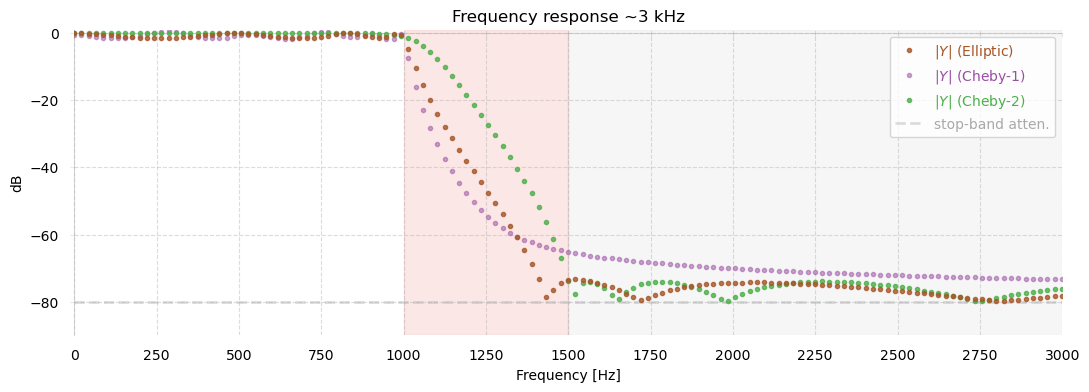

In [34]:
# --------------------------------------------------------------------
# Frequency response: compare Y (Cheby-1), Y (Cheby-2), and Y (Elliptic)
#
fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Frequency response ~3 kHz')
ax.set(ylabel='dB', xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set(ylim=[-90, 1.], xlim=[-0.5, 3000])
ax.set_yticks([0, -20, -40, -60, -80])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=224, color='#A9A9A940')

ax.step(freqs, 20 * np.log10(np.abs(Y_ell) + 1e-4), linestyle='', marker='.', zorder=5, label=r'$|Y|$ (Elliptic)', alpha=0.8, color='#a65628')
ax.step(freqs, 20 * np.log10(np.abs(Y_cheby1) + 1e-4), linestyle='', marker='.', zorder=3, label='$|Y|$ (Cheby-1)', alpha=0.5, color='#984ea3')
ax.step(freqs, 20 * np.log10(np.abs(Y_cheby2) + 1e-4), linestyle='', marker='.', zorder=4, label='$|Y|$ (Cheby-2)', alpha=0.8, color='#4daf4a')

ax.axvspan(1000, 1500, zorder=-2, color='#e41a1c', alpha=0.1)
ax.axvspan(1500, freqs[-1], zorder=-2, color='#A9A9A9', alpha=0.1)
ax.axhline(-80, label='stop-band atten.', zorder=-1, linewidth=2, color='#A9A9A9', linestyle='--', alpha=0.4)

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')

plt.show()

##### _Answer 1_

* <span style="background-color:rgba(247,129,191,0.3)">Butterworth</span> is not even in the running.
* <span style="background-color:rgba(152,78,163,0.3)">Chebyshev Type-1</span> can't satisfy the requirment of a stop-band attenuation of at least 80 dB.
* <span style="background-color:rgba(77,175,74,0.3)">Chebyshev Type-2</span> comes close, but it doesn't seem to fully meet that requirement of a transition width of max. 500 Hz.
* Only the <span style="background-color:rgba(166,86,40,0.3)">Elliptic</span> filter can meet the requirements in this exercise.

##### _Answer 2_

* `scipy.signal.cheb1ord`, order = 11
* `scipy.signal.cheb2ord`, order = 11
* `scipy.signal.ellipord`, order = 7

##### _Answer 3_

Using the Parks-McClellan method as explained earlier in Ch. 10 (c.f. [`scipy.signal.remez`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.remez.html#remez), the following plausible values for $f_{cutoff}$ and the amount to further scale order $\lfloor\frac{f_{s}}{f_{cutoff}}\rfloor$ were found.

1. $f_{cutoff}$ = 700 Hz, and order = $24 \cdot \lfloor\frac{f_{s}}{f_{cutoff}}\rfloor$
2. $f_{cutoff}$ = 750 Hz, and order = $23 \cdot \lfloor\frac{f_{s}}{f_{cutoff}}\rfloor$
3. $f_{cutoff}$ = 800 Hz, and order = $19 \cdot \lfloor\frac{f_{s}}{f_{cutoff}}\rfloor$

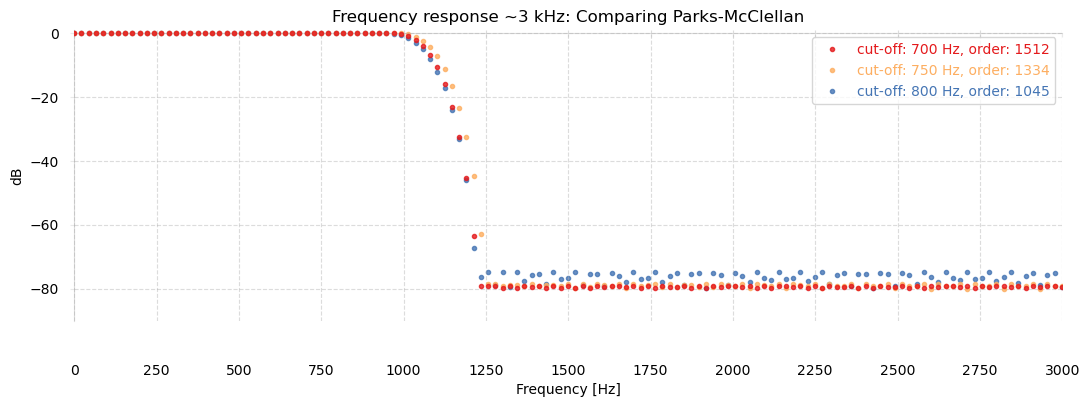

In [35]:
# these values were found by trial & error
recutoff2scale = {
    700: 24,
    750: 23,
    800: 19
}

remez_check = {}

for f_cutoff, scale in recutoff2scale.items():
    _order = fs // f_cutoff
    # Build the filter using the Remez method
    # We'll use the following bands:
    #    Pass band: [0, 0.75 * f_cutoff]  (begin to transition at 75% of our cutoff)
    #          gain: 1
    #    Stop band: [f_cutoff, fs/2]  (attenuate everything above the cutoff)
    #          gain: 0
    _hpm = sp.signal.remez(
        scale*_order, 
        [0, 0.75*f_cutoff, f_cutoff, fs/2],  # Our frequency bands
        [1, 0],  # Our target gain for each band
        fs=fs
    )
    _y = sp.signal.convolve(x, _hpm)
    remez_check[f_cutoff] = {
        'Y': np.fft.rfft(_y),
        'desc': f"cut-off: {f_cutoff} Hz, order: {scale*_order}"
    }

fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Frequency response ~3 kHz: Comparing Parks-McClellan')
ax.set(ylabel='dB', xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set_yticks([0, -20, -40, -60, -80])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=235, color='#A9A9A940')

ax.step(freqs, 20 * np.log10(np.abs(remez_check[700]['Y'])[:len(freqs)] + 1e-4), linestyle='', marker='.', zorder=3, label=remez_check[700]["desc"], alpha=0.8, color='#e41a1c')
ax.step(freqs, 20 * np.log10(np.abs(remez_check[750]['Y'])[:len(freqs)] + 1e-4), linestyle='', marker='.', zorder=2, label=remez_check[750]["desc"], alpha=0.8, color='#fdae61')
ax.step(freqs, 20 * np.log10(np.abs(remez_check[800]['Y'])[:len(freqs)] + 1e-4), linestyle='', marker='.', zorder=1, label=remez_check[800]["desc"], alpha=0.8, color='#4575b4')

ax.set(ylim=[-90., 0.9], xlim=[-0.5, 3000])
ax.set(ylabel='dB')

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')
plt.show()

_Let's try a Parks-McClellan filter using $f_{cutoff}$ = 700 Hz, and order = $24 \cdot \lfloor\frac{f_{s}}{f_{cutoff}}\rfloor$, and see how that compares to our <span style="background-color:rgba(166,86,40,0.3)">Elliptic</span> filter._

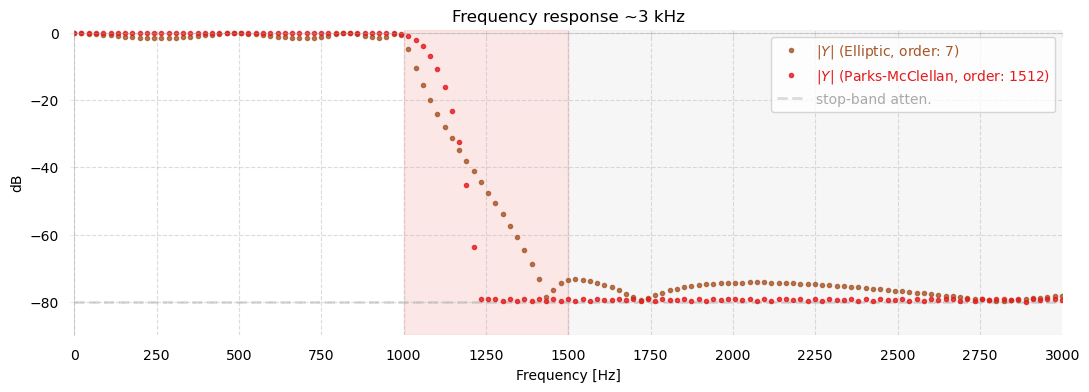

In [36]:
# --------------------------------------------------------------------
# Frequency response: compare Y (Elliptic) vs Y (Parks-McClellan)
#
fig, ax = plt.subplots(figsize=(11, 4))

ax.set(title='Frequency response ~3 kHz')
ax.set(ylabel='dB', xlabel='Frequency [Hz]')
ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)
ax.set(ylim=[-90, 1.], xlim=[-0.5, 3000])
ax.set_yticks([0, -20, -40, -60, -80])
ax.set_xticks([0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000])
ax.tick_params(axis='y', which=u'both', length=3, pad=8, color='#A9A9A940')
ax.tick_params(axis='x', which=u'both', length=3, pad=224, color='#A9A9A940')

ax.step(freqs, 20 * np.log10(np.abs(Y_ell) + 1e-4), linestyle='', marker='.', label=r'$|Y|$ (Elliptic, order: 7)', alpha=0.8, color='#a65628')
ax.step(freqs, 20 * np.log10(np.abs(remez_check[700]['Y'])[:len(freqs)] + 1e-4), linestyle='', marker='.', label=r'$|Y|$ (Parks-McClellan, order: 1512)', alpha=0.8, color='#e41a1c')

ax.axvspan(1000, 1500, zorder=-2, color='#e41a1c', alpha=0.1)
ax.axvspan(1500, freqs[-1], zorder=-2, color='#A9A9A9', alpha=0.1)
ax.axhline(-80, label='stop-band atten.', zorder=-1, linewidth=2, color='#A9A9A9', linestyle='--', alpha=0.4)

fig.tight_layout()
ax.legend(loc='upper right', labelcolor='linecolor')

plt.show()

_While a <span style="background-color:rgba(228,26,28,0.3)">Parks-McClellan filter using $f_{cutoff}$ = 700 Hz and raising order $K$ to 1512</span> looks to satisfy the original requirement in 11.3, that level of filter order is 3 magnitudes greater than the <span style="background-color:rgba(166,86,40,0.3)">Elliptic</span> filter._